# Fama-MacBeth Regression

In [1]:
from empfin import FamaMacBeth, ff25p, ff5f
import pandas as pd

The Fama-MacBeth (1973) procedure is a two-pass estimator for factor risk premia.

The **first pass** runs, for each asset $i$, a time-series regression of the excess return on the factor(s) with an intercept.

The **second pass** runs, in each period $t$, a cross-sectional OLS regression of that period's asset returns on the first-pass betas with an intercept, yielding a time series of slope estimates $\hat\lambda_t$. The risk premium estimate for each factor is the time-series mean $\hat\lambda = \frac{1}{T}\sum_t \hat\lambda_t$, and the classical Fama-MacBeth standard error is $\mathrm{SE}(\hat\lambda) = \mathrm{sd}(\hat\lambda_t)/\sqrt{T}$.

Let us load the Fama-French 5 factors and the 25 size-value double-sorted portfolios.

In [16]:
ports = ff25p()
facts, _ = ff5f()

## Single-factor model

Let's start with the **market model**, i.e. one factor (`Mkt-RF`). For each test asset $i$, the first stage estimates
$$
R_{i,t} = a_i + \beta_i R_{mkt,t} + \varepsilon_{i,t}
$$
At each period $t$, the second stage runs the cross-sectional regression
$$
R_{i,t} = \lambda_{0,t} + \lambda_{1,t} \hat\beta_i + \alpha_{i,t}
$$

In [3]:
fm_mkt = FamaMacBeth(
    assets=ports,
    factors=facts["Mkt-RF"],
)

The attribute `betas` holds the first-pass loadings.

In [4]:
fm_mkt.betas

,ME1 BM1,ME1 BM2,ME1 BM3,ME1 BM4,ME1 BM5,ME2 BM1,ME2 BM2,ME2 BM3,ME2 BM4,ME2 BM5,...,ME4 BM1,ME4 BM2,ME4 BM3,ME4 BM4,ME4 BM5,ME5 BM1,ME5 BM2,ME5 BM3,ME5 BM4,ME5 BM5
Mkt-RF,1.41473,1.223423,1.114278,1.04134,1.069196,1.378227,1.185572,1.080903,1.023522,1.148715,...,1.196648,1.078299,1.01225,0.993598,1.086127,0.988131,0.925566,0.863315,0.893685,0.987865


The attribute `lambdas_t` is the period-by-period time series of cross-sectional slopes. The risk premium estimate and all inference are built from this series.

In [17]:
fm_mkt.lambdas_t.tail()

,const,Mkt-RF
Date,,
2025-04-30,-12.762986,9.337169
2025-05-31,-1.080023,5.709333
2025-06-30,-2.049168,6.661195
2025-07-31,-2.961766,3.793003
2025-08-31,-3.269462,8.567265


The point estimates `lambdas` are the time-series means of `lambdas_t`.

In [6]:
fm_mkt.lambdas

const     1.133340
Mkt-RF   -0.358935
Name: Lambdas, dtype: float64

Standard errors, t-statistics, and p-values are reported together with the point estimates.

In [7]:
pd.DataFrame({
    "estimate": fm_mkt.lambdas,
    "SE": fm_mkt.lambdas_se,
    "t-stat": fm_mkt.lambdas_tstat,
    "p-value": fm_mkt.lambdas_pvalue,
})

,estimate,SE,t-stat,p-value
const,1.133340,0.378575,2.993702,0.002847
Mkt-RF,-0.358935,0.405779,-0.884556,0.376682


The `FamaMacBeth` class has two summary charts. The first shows the time-averaged pricing errors, the risk premia, and predicted-vs-realized average returns.

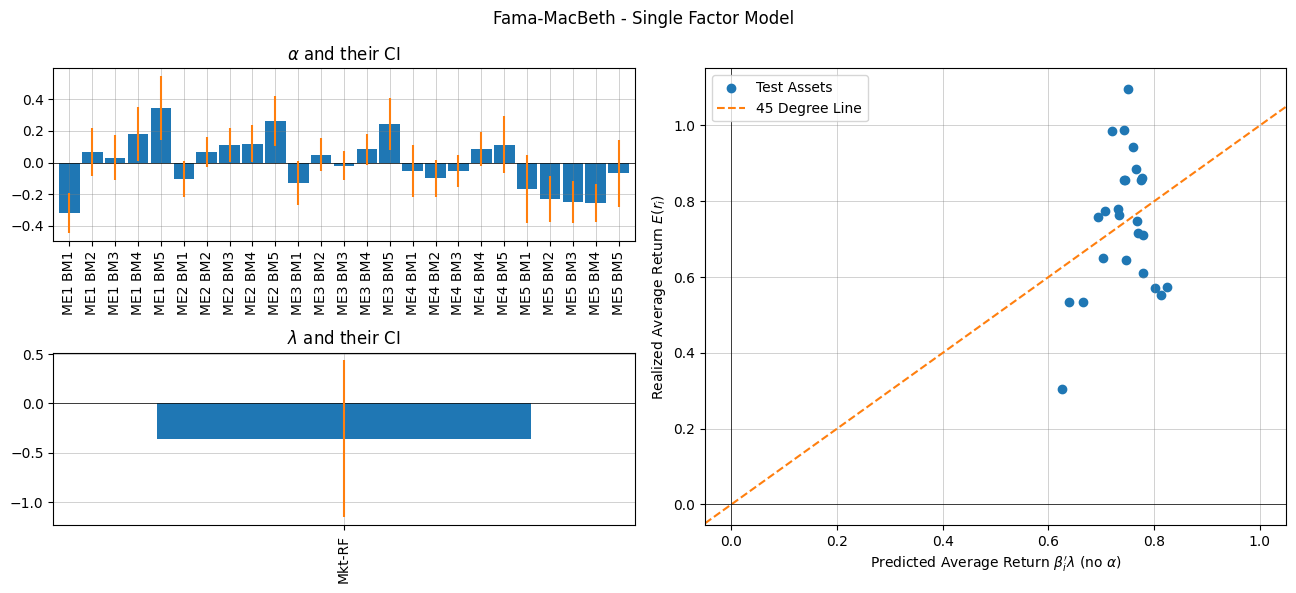

In [8]:
fm_mkt.plot_alpha_pred(title="Fama-MacBeth - Single Factor Model")

The second plots the time series of cross-sectional slopes $\lambda_t$ for each coefficient, with the Fama-MacBeth point estimate overlaid as a horizontal reference.

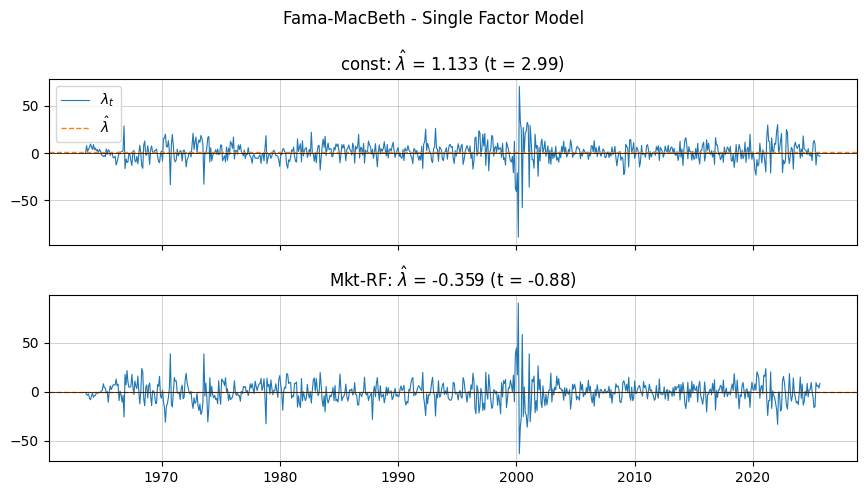

In [9]:
fm_mkt.plot_lambdas_timeseries(title="Fama-MacBeth - Single Factor Model")

## Five-factor model

Now run the same procedure with the **5 Fama-French factors**.

In [10]:
fm_5f = FamaMacBeth(ports, facts)
pd.DataFrame({
    "estimate": fm_5f.lambdas,
    "SE": fm_5f.lambdas_se,
    "t-stat": fm_5f.lambdas_tstat,
    "p-value": fm_5f.lambdas_pvalue,
})

,estimate,SE,t-stat,p-value
const,0.891147,0.267808,3.327555,0.000919
Mkt-RF,-0.341343,0.315367,-1.082369,0.279439
SMB,0.247902,0.113840,2.177636,0.029746
HML,0.278952,0.111346,2.505263,0.012448
RMW,0.430059,0.164933,2.607470,0.009304
CMA,0.005808,0.169940,0.034175,0.972747


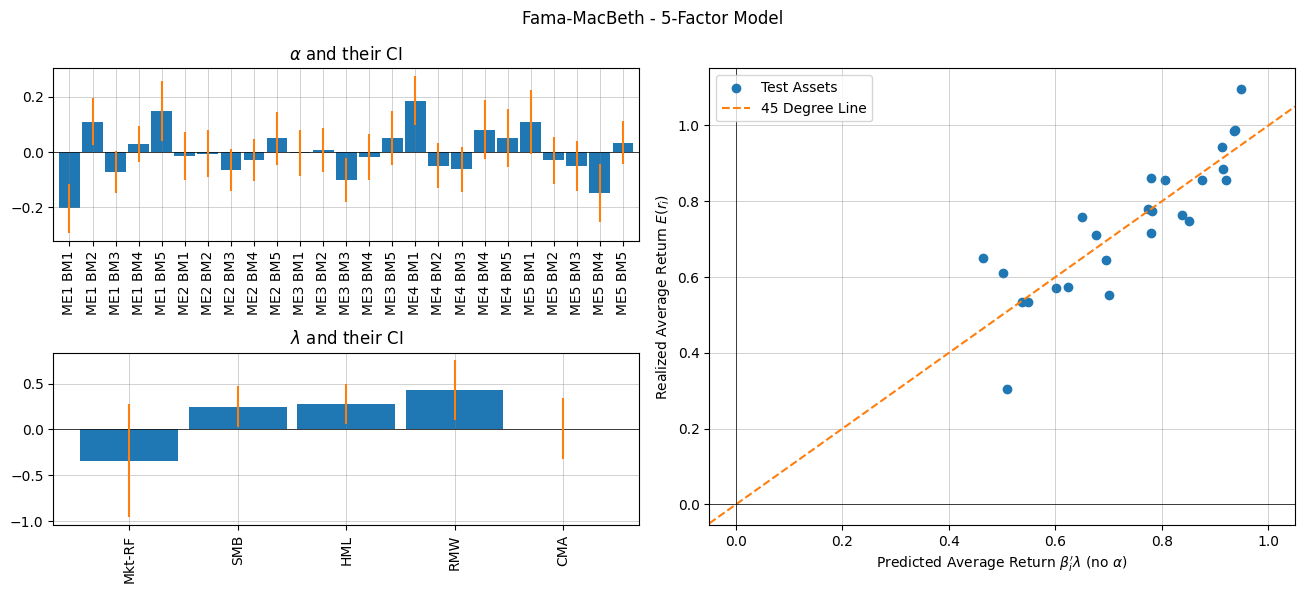

In [11]:
fm_5f.plot_alpha_pred(title="Fama-MacBeth - 5-Factor Model")

## Newey-West standard errors

When the cross-sectional slopes $\lambda_t$ are serially correlated, the classical Fama-MacBeth standard errors understate the true sampling uncertainty. Passing `nw_lags=L` computes Newey-West HAC standard errors on the $\lambda_t$ series with a Bartlett kernel and truncation lag $L$.

In [12]:
fm_5f_nw = FamaMacBeth(ports, facts, nw_lags=4)
pd.DataFrame({
    "FM SE": fm_5f.lambdas_se,
    "Newey-West SE": fm_5f_nw.lambdas_se,
})

,FM SE,Newey-West SE
const,0.267808,0.250806
Mkt-RF,0.315367,0.282675
SMB,0.113840,0.115979
HML,0.111346,0.130178
RMW,0.164933,0.172407
CMA,0.169940,0.181109


## Shanken (1992) errors-in-variables correction

The first-pass betas are estimated, not known. Shanken (1992) showed that the second-pass standard errors should be inflated by the multiplicative factor $1 + \hat\lambda' \hat\Sigma_f^{-1} \hat\lambda$, where $\hat\Sigma_f$ is the sample factor covariance and $\hat\lambda$ excludes the intercept. Passing `shanken=True` applies this correction; it composes with `nw_lags` if both are set.

In [13]:
fm_5f_sh = FamaMacBeth(ports, facts, shanken=True)
print(f"Shanken factor: {fm_5f_sh.shanken_factor:.4f}")
pd.DataFrame({
    "FM SE": fm_5f.lambdas_se,
    "Shanken SE": fm_5f_sh.lambdas_se,
})

Shanken factor: 1.0764


,FM SE,Shanken SE
const,0.267808,0.277857
Mkt-RF,0.315367,0.327199
SMB,0.113840,0.118111
HML,0.111346,0.115524
RMW,0.164933,0.171122
CMA,0.169940,0.176316


## Rolling-window first pass

By default the first-pass betas are estimated once over the full sample. Setting `rolling_window=w` re-estimates the betas at each $t$ over the window $[t-w+1, t]$ (inclusive, ending at $t$ -- no future data is used), giving a panel of time-varying betas that feeds the cross-sectional second pass.

In [14]:
fm_roll = FamaMacBeth(ports, facts, rolling_window=60)
pd.DataFrame({
    "Full-sample": fm_5f.lambdas,
    "Rolling 60m": fm_roll.lambdas,
})

Rolling first-pass: 100%|██████████| 687/687 [00:00<00:00, 5374.99it/s]


,Full-sample,Rolling 60m
const,0.891147,0.903998
Mkt-RF,-0.341343,-0.306975
SMB,0.247902,0.093922
HML,0.278952,0.274079
RMW,0.430059,0.307638
CMA,0.005808,0.171875


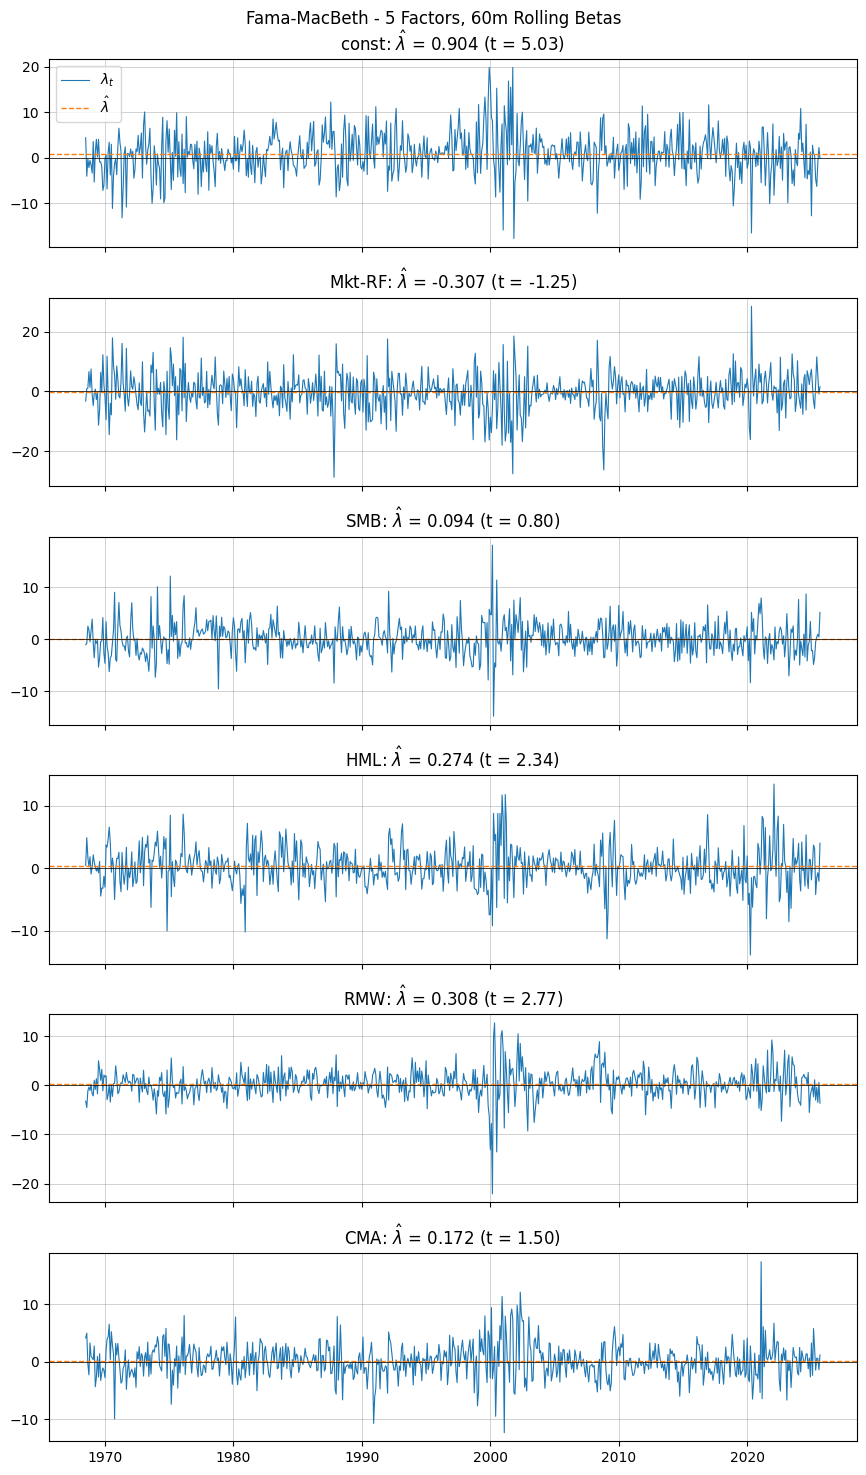

In [15]:
fm_roll.plot_lambdas_timeseries(title="Fama-MacBeth - 5 Factors, 60m Rolling Betas")